# Notebook 03 : Comparaison de 5 Modèles de Machine Learning

## Contexte

**Objectif :** Comparer **5 modèles** de machine learning et sélectionner le meilleur pour la prédiction de défaut de paiement.

**Métrique principale : AUC (Area Under the ROC Curve)**

L'AUC mesure la capacité du modèle à discriminer entre les classes 0 (remboursement) et 1 (défaut). Plus l'AUC est proche de 1, meilleur est le modèle.

**Pourquoi pas l'accuracy ?**
- Dataset déséquilibré (92% classe 0, 8% classe 1)
- Un modèle prédisant toujours 0 aurait 92% d'accuracy mais AUC = 0.5
- L'AUC évalue la capacité à bien ordonner les prédictions, pas juste la précision

**Métrique métier : Coût = 10×FN + 1×FP**
- FN (Faux Négatif) : Prêter à un client qui fera défaut → Coût élevé (10€)
- FP (Faux Positif) : Refuser un bon client → Coût faible (1€)

## Modèles évalués (Conforme recommandations mentor)

### 1. DummyClassifier (Baseline naïve)
**Description :** Prédit toujours la classe majoritaire (0 = remboursement)

**Utilité :** Établir un plancher de performance. Tout modèle doit faire mieux que le Dummy.

**Performance attendue :**
- AUC : ~0.50 (équivalent à un tirage aléatoire)
- Coût métier : ~32,000€ (le plus élevé)

---

### 2. Régression Logistique
**Description :** Modèle linéaire avec fonction sigmoïde

**Avantages :**
- Simple et interprétable (coefficients)
- Rapide à entraîner
- Robuste, peu sujet à l'overfitting

**Limites :**
- Assume une relation linéaire
- Ne capture pas les interactions complexes

**Performance attendue :**
- AUC : 0.54-0.56
- Coût métier : ~29,000€

---

### 3. Random Forest
**Description :** Ensemble de decision trees entraînés sur des sous-échantillons

**Avantages :**
- Capture les interactions non-linéaires
- Robuste au surapprentissage (grâce au bagging)
- Gère bien les features corrélées

**Paramètres clés :**
- `n_estimators` : Nombre d'arbres (100-500)
- `max_depth` : Profondeur maximale
- `min_samples_split` : Échantillons minimum pour split

**Performance attendue :**
- AUC : 0.74-0.76
- Coût métier : ~27,000€

---

### 4. XGBoost (Extreme Gradient Boosting)
**Description :** Gradient boosting optimisé avec régularisation

**Avantages :**
- Très performant sur données tabulaires
- Régularisation L1/L2 intégrée
- Gère nativement les valeurs manquantes
- Parallélisation efficace

**Paramètres clés :**
- `n_estimators` : Nombre d'arbres
- `max_depth` : Profondeur (3-10)
- `learning_rate` : Taux d'apprentissage (0.01-0.1)
- `colsample_bytree` : Fraction de features par arbre

**Performance attendue :**
- AUC : 0.77-0.79
- Coût métier : ~26,000€

---

### 5. LightGBM (Gradient Boosting)
**Description :** Gradient boosting optimisé pour rapidité et efficacité mémoire

**Avantages :**
- Plus rapide que XGBoost
- Très efficace en mémoire
- Gère nativement les valeurs manquantes
- Excellentes performances sur gros datasets

**Paramètres clés :**
- `n_estimators` : Nombre d'arbres
- `max_depth` : Profondeur maximale
- `learning_rate` : Taux d'apprentissage
- `num_leaves` : Nombre de feuilles par arbre

**Performance attendue :**
- AUC : 0.77-0.80 (meilleur attendu)
- Coût métier : ~25,000€ (le plus bas)

## Imports et Configuration

In [2]:
# Imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

import mlflow
import mlflow.sklearn
import mlflow.lightgbm

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score
)

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

print(" Imports OK")


C:\Users\Utilisateur\anaconda3\envs\mon_env\lib\site-packages\pydantic\_internal\_fields.py:149: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


 Imports OK


In [3]:
# ============================================================================
# CONFIGURATION MLFLOW
# ============================================================================

# Définir l'expérience MLFlow
EXPERIMENT_NAME = "P7_Comparaison_Modeles_Scoring_Credit"
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment(EXPERIMENT_NAME)

print(f" Expérience MLFlow : '{EXPERIMENT_NAME}'")
print(f" Tracking URI      : ./mlruns")
print("")
print("Pour visualiser l'UI MLFlow, exécuter dans un terminal :")
print("  mlflow ui --backend-store-uri ./mlruns")
print("  → Ouvrir : http://localhost:5000")


C:\Users\Utilisateur\anaconda3\envs\mon_env\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/03 12:53:54 INFO mlflow.tracking.fluent: Experiment with name 'P7_Comparaison_Modeles_Scoring_Credit' does not exist. Creating a new experiment.


 Expérience MLFlow : 'P7_Comparaison_Modeles_Scoring_Credit'
 Tracking URI      : ./mlruns

Pour visualiser l'UI MLFlow, exécuter dans un terminal :
  mlflow ui --backend-store-uri ./mlruns
  → Ouvrir : http://localhost:5000


## Chargement des Données Preprocessed

Chargement direct des données déjà preprocessed du Notebook 02 :
- `X_train_processed.joblib` : Données train transformées (804 features)
- `X_valid_processed.joblib` : Données validation transformées (804 features)
- `y_train.joblib` : Labels train
- `y_valid.joblib` : Labels validation

In [4]:
# ============================================================================
# CHARGEMENT DES DONNÉES TRANSFORMÉES (déjà prêtes depuis Notebook 02)
# ============================================================================

print("\nChargement des données depuis Notebook 02...\n")

# Chargement des données DÉJÀ transformées (pas besoin de re-transformer)
X_train_processed = joblib.load('./artifacts/X_train_processed.joblib')
X_valid_processed = joblib.load('./artifacts/X_valid_processed.joblib')
y_train = joblib.load('./artifacts/y_train.joblib')
y_valid = joblib.load('./artifacts/y_valid.joblib')

print(f"   X_train_processed : {X_train_processed.shape}")
print(f"   X_valid_processed : {X_valid_processed.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   y_valid : {y_valid.shape}")

# Vérifier le type
print(f"\n   Type X_train_processed : {type(X_train_processed)}")

if hasattr(X_train_processed, 'columns'):
    print(f"   DataFrame avec colonnes nommées")
    print(f"   Colonnes (5 premières) : {X_train_processed.columns.tolist()[:5]}")
else:
    print(f"   ATTENTION : Type array sans noms de colonnes !")

# Vérifier les NaN
if hasattr(X_train_processed, 'isna'):
    # DataFrame
    nan_count = X_train_processed.isna().sum().sum()
else:
    # Array
    nan_count = np.isnan(X_train_processed).sum()

print(f"\n   NaN dans X_train_processed : {nan_count}")

print("\nDonnées prêtes pour la modélisation !")



Chargement des données depuis Notebook 02...

   X_train_processed : (246005, 804)
   X_valid_processed : (61502, 804)
   y_train : (246005,)
   y_valid : (61502,)

   Type X_train_processed : <class 'pandas.core.frame.DataFrame'>
   DataFrame avec colonnes nommées
   Colonnes (5 premières) : ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL']

   NaN dans X_train_processed : 0

Données prêtes pour la modélisation !


## Vérification et Nettoyage des NaN

**Problème potentiel** : Les artifacts peuvent contenir des NaN résiduels.

**Solution** : Vérifier et nettoyer avec `np.nan_to_num()` si nécessaire.

In [5]:
# Vérifier les NaN
nan_train = np.isnan(X_train_processed).sum().sum()
nan_valid = np.isnan(X_valid_processed).sum().sum()

print("Vérification des NaN :")
print(f"X_train_processed : {nan_train:,} NaN")
print(f"X_valid_processed : {nan_valid:,} NaN")

# Nettoyer si nécessaire
if nan_train > 0 or nan_valid > 0:
    print("\nATTENTION : NaN détectés !")
    print("Nettoyage avec np.nan_to_num() (remplace NaN par 0)...")

    X_train_processed = np.nan_to_num(X_train_processed, nan=0.0, copy=False)
    X_valid_processed = np.nan_to_num(X_valid_processed, nan=0.0, copy=False)

    # Vérification finale
    nan_train_after = np.isnan(X_train_processed).sum().sum()
    nan_valid_after = np.isnan(X_valid_processed).sum().sum()

    print("Nettoyage terminé :")
    print(f"X_train_processed : {nan_train_after:,} NaN")
    print(f"X_valid_processed : {nan_valid_after:,} NaN")

else:
    print("\nPas de NaN détectés - Données prêtes !")


Vérification des NaN :
X_train_processed : 0 NaN
X_valid_processed : 0 NaN

Pas de NaN détectés - Données prêtes !


In [6]:
# Charger les artifacts du Notebook 02
X_train_processed = joblib.load('./artifacts/X_train_processed.joblib')
X_valid_processed = joblib.load('./artifacts/X_valid_processed.joblib')
y_train = joblib.load('./artifacts/y_train.joblib')
y_valid = joblib.load('./artifacts/y_valid.joblib')

print(" Données chargées")
print(f" X_train shape : {X_train_processed.shape}")
print(f" X_valid shape : {X_valid_processed.shape}")
print(f" y_train shape : {y_train.shape}")
print(f" y_valid shape : {y_valid.shape}")

# Vérifier le déséquilibre
print(f"\n Déséquilibre :")
print(f" Classe 0 : {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f" Classe 1 : {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")

 Données chargées
 X_train shape : (246005, 804)
 X_valid shape : (61502, 804)
 y_train shape : (246005,)
 y_valid shape : (61502,)

 Déséquilibre :
 Classe 0 : 226,145 (91.9%)
 Classe 1 : 19,860 (8.1%)


In [7]:
# ============================================
# CORRECTION : Imputation finale des NaN
# ============================================

print("\nCorrection : Imputation des NaN residuels...\n")

from sklearn.impute import SimpleImputer

# Compter les NaN avant (total)
nan_before_train = np.isnan(X_train_processed).sum().sum()
nan_before_valid = np.isnan(X_valid_processed).sum().sum()

print("NaN avant imputation :")
print(f" Train : {nan_before_train:,}")
print(f" Valid : {nan_before_valid:,}")

# Imputation avec la mediane
imputer_final = SimpleImputer(strategy='median')
X_train_processed = imputer_final.fit_transform(X_train_processed)
X_valid_processed = imputer_final.transform(X_valid_processed)

# Compter les NaN après (total)
nan_after_train = np.isnan(X_train_processed).sum().sum()
nan_after_valid = np.isnan(X_valid_processed).sum().sum()

print("\nNaN apres imputation :")
print(f" Train : {nan_after_train:,}")
print(f" Valid : {nan_after_valid:,}")

if nan_after_train == 0 and nan_after_valid == 0:
    print("\nImputation reussie - Aucun NaN residuel")
else:
    print(f"\nATTENTION : {nan_after_train + nan_after_valid:,} NaN persistent")

print("\nShapes finaux :")
print(f" X_train_processed : {X_train_processed.shape}")
print(f" X_valid_processed : {X_valid_processed.shape}")

print("\nDonnees pretes pour la modelisation")



Correction : Imputation des NaN residuels...

NaN avant imputation :
 Train : 0
 Valid : 0

NaN apres imputation :
 Train : 0
 Valid : 0

Imputation reussie - Aucun NaN residuel

Shapes finaux :
 X_train_processed : (246005, 804)
 X_valid_processed : (61502, 804)

Donnees pretes pour la modelisation


## Modèle 1 : DummyClassifier (Baseline)

In [8]:
# ── Run MLFlow : DummyClassifier ─────────────────────────────────────────
with mlflow.start_run(run_name="DummyClassifier"):

    mlflow.log_params({"strategy": "most_frequent", "random_state": 42})

    # Entraînement
    dummy = DummyClassifier(strategy='most_frequent', random_state=42)
    start = time.time()
    dummy.fit(X_train_processed, y_train)
    time_dummy = time.time() - start

    # Prédictions
    y_pred_dummy = dummy.predict(X_valid_processed)
    y_proba_dummy = dummy.predict_proba(X_valid_processed)[:, 1]

    # Métriques
    auc_dummy = roc_auc_score(y_valid, y_proba_dummy)
    recall_dummy = recall_score(y_valid, y_pred_dummy)
    precision_dummy = precision_score(y_valid, y_pred_dummy, zero_division=0)
    f1_dummy = f1_score(y_valid, y_pred_dummy, zero_division=0)
    cout_dummy = 10 * (y_valid[y_pred_dummy == 0].sum()) + 1 * ((1 - y_valid)[y_pred_dummy == 1].sum())

    mlflow.log_metrics({
        "auc": auc_dummy,
        "recall": recall_dummy,
        "precision": precision_dummy,
        "f1": f1_dummy,
        "cout_metier": float(cout_dummy),
        "temps_entrainement_s": time_dummy
    })
    mlflow.sklearn.log_model(dummy, artifact_path="dummy_classifier")
    print("  MLFlow run 'DummyClassifier' enregistré.")

print(f"DummyClassifier - AUC: {auc_dummy:.4f} | Coût: {cout_dummy}")


2026/03/03 12:55:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 12:55:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MLFlow run 'DummyClassifier' enregistré.
DummyClassifier - AUC: 0.5000 | Coût: 49650


## Modèle 2 : Logistic Regression

In [9]:
# ── Run MLFlow : LogisticRegression ──────────────────────────────────────
with mlflow.start_run(run_name="LogisticRegression"):

    mlflow.log_params({"max_iter": 1000, "random_state": 42, "n_jobs": -1})

    logreg = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    start = time.time()
    logreg.fit(X_train_processed, y_train)
    time_logreg = time.time() - start

    y_pred_logreg = logreg.predict(X_valid_processed)
    y_proba_logreg = logreg.predict_proba(X_valid_processed)[:, 1]

    auc_logreg = roc_auc_score(y_valid, y_proba_logreg)
    recall_logreg = recall_score(y_valid, y_pred_logreg)
    precision_logreg = precision_score(y_valid, y_pred_logreg)
    f1_logreg = f1_score(y_valid, y_pred_logreg)
    cout_logreg = 10 * (y_valid[y_pred_logreg == 0].sum()) + 1 * ((1 - y_valid)[y_pred_logreg == 1].sum())

    # Cross-validation AUC (5-fold)
    cv_scores_logreg = cross_val_score(logreg, X_train_processed, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    mlflow.log_metric("cv_auc_mean", cv_scores_logreg.mean())
    mlflow.log_metric("cv_auc_std", cv_scores_logreg.std())

    mlflow.log_metrics({
        "auc": auc_logreg,
        "recall": recall_logreg,
        "precision": precision_logreg,
        "f1": f1_logreg,
        "cout_metier": float(cout_logreg),
        "temps_entrainement_s": time_logreg
    })
    mlflow.sklearn.log_model(logreg, artifact_path="logistic_regression")
    print("  MLFlow run 'LogisticRegression' enregistré.")

print(f"LogisticRegression - AUC: {auc_logreg:.4f} | CV AUC: {cv_scores_logreg.mean():.4f} ± {cv_scores_logreg.std():.4f}")


2026/03/03 13:12:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 13:12:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MLFlow run 'LogisticRegression' enregistré.
LogisticRegression - AUC: 0.5485 | CV AUC: 0.5498 ± 0.0049


## Modèle 3 : Random Forest

In [10]:
# ── Run MLFlow : RandomForest ─────────────────────────────────────────────
with mlflow.start_run(run_name="RandomForest"):

    rf_params = {"n_estimators": 200, "max_depth": 10, "min_samples_split": 10, "random_state": 42}
    mlflow.log_params(rf_params)

    rf = RandomForestClassifier(**rf_params, n_jobs=-1, verbose=0)
    start = time.time()
    rf.fit(X_train_processed, y_train)
    time_rf = time.time() - start

    y_pred_rf = rf.predict(X_valid_processed)
    y_proba_rf = rf.predict_proba(X_valid_processed)[:, 1]

    auc_rf = roc_auc_score(y_valid, y_proba_rf)
    recall_rf = recall_score(y_valid, y_pred_rf)
    precision_rf = precision_score(y_valid, y_pred_rf)
    f1_rf = f1_score(y_valid, y_pred_rf)
    cout_rf = 10 * (y_valid[y_pred_rf == 0].sum()) + 1 * ((1 - y_valid)[y_pred_rf == 1].sum())

    mlflow.log_metrics({
        "auc": auc_rf,
        "recall": recall_rf,
        "precision": precision_rf,
        "f1": f1_rf,
        "cout_metier": float(cout_rf),
        "temps_entrainement_s": time_rf
    })
    mlflow.sklearn.log_model(rf, artifact_path="random_forest")
    print("  MLFlow run 'RandomForest' enregistré.")

print(f"RandomForest - AUC: {auc_rf:.4f} | Coût: {cout_rf}")


C:\Users\Utilisateur\anaconda3\envs\mon_env\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2026/03/03 13:14:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 13:14:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MLFlow run 'RandomForest' enregistré.
RandomForest - AUC: 0.7471 | Coût: 49650


## Modèle 4 : XGBoost

In [11]:
# ── Run MLFlow : XGBoost ──────────────────────────────────────────────────
with mlflow.start_run(run_name="XGBoost"):

    xgb_params = {"n_estimators": 200, "max_depth": 7, "learning_rate": 0.05, "random_state": 42}
    mlflow.log_params(xgb_params)

    xgb = XGBClassifier(**xgb_params, n_jobs=-1, verbosity=0)
    start = time.time()
    xgb.fit(X_train_processed, y_train)
    time_xgb = time.time() - start

    y_pred_xgb = xgb.predict(X_valid_processed)
    y_proba_xgb = xgb.predict_proba(X_valid_processed)[:, 1]

    auc_xgb = roc_auc_score(y_valid, y_proba_xgb)
    recall_xgb = recall_score(y_valid, y_pred_xgb)
    precision_xgb = precision_score(y_valid, y_pred_xgb)
    f1_xgb = f1_score(y_valid, y_pred_xgb)
    cout_xgb = 10 * (y_valid[y_pred_xgb == 0].sum()) + 1 * ((1 - y_valid)[y_pred_xgb == 1].sum())

    mlflow.log_metrics({
        "auc": auc_xgb,
        "recall": recall_xgb,
        "precision": precision_xgb,
        "f1": f1_xgb,
        "cout_metier": float(cout_xgb),
        "temps_entrainement_s": time_xgb
    })
    mlflow.sklearn.log_model(xgb, artifact_path="xgboost")
    print("  MLFlow run 'XGBoost' enregistré.")

print(f"XGBoost - AUC: {auc_xgb:.4f} | Coût: {cout_xgb}")


2026/03/03 13:15:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 13:15:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MLFlow run 'XGBoost' enregistré.
XGBoost - AUC: 0.7837 | Coût: 47788


## Modèle 5 : LightGBM

In [12]:
# ── Run MLFlow : LightGBM (modèle retenu) ────────────────────────────────
with mlflow.start_run(run_name="LightGBM"):

    lgbm_params = {
        "n_estimators": 500,
        "max_depth": 7,
        "learning_rate": 0.05,
        "random_state": 42,
    }
    mlflow.log_params(lgbm_params)

    lgbm = lgb.LGBMClassifier(**lgbm_params, n_jobs=-1, verbose=-1)
    start = time.time()
    lgbm.fit(X_train_processed, y_train)
    time_lgbm = time.time() - start

    y_pred_lgbm = lgbm.predict(X_valid_processed)
    y_proba_lgbm = lgbm.predict_proba(X_valid_processed)[:, 1]

    auc_lgbm = roc_auc_score(y_valid, y_proba_lgbm)
    recall_lgbm = recall_score(y_valid, y_pred_lgbm)
    precision_lgbm = precision_score(y_valid, y_pred_lgbm)
    f1_lgbm = f1_score(y_valid, y_pred_lgbm)
    cout_lgbm = 10 * (y_valid[y_pred_lgbm == 0].sum()) + 1 * ((1 - y_valid)[y_pred_lgbm == 1].sum())

    mlflow.log_metrics({
        "auc": auc_lgbm,
        "recall": recall_lgbm,
        "precision": precision_lgbm,
        "f1": f1_lgbm,
        "cout_metier": float(cout_lgbm),
        "temps_entrainement_s": time_lgbm
    })
    mlflow.lightgbm.log_model(lgbm, artifact_path="lightgbm")
    print("  MLFlow run 'LightGBM' enregistré.")

print(f"LightGBM - AUC: {auc_lgbm:.4f} | Coût: {cout_lgbm}")


2026/03/03 13:16:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 13:16:37 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MLFlow run 'LightGBM' enregistré.
LightGBM - AUC: 0.7868 | Coût: 47620


## Optimisation des Hyperparamètres — LightGBM (RandomizedSearchCV + MLFlow)

Conformément aux exigences du référentiel (CE7), nous effectuons une **validation croisée**
avec exploration d'hyperparamètres via `RandomizedSearchCV`.

- **Méthode :** RandomizedSearchCV (plus rapide que GridSearchCV sur 804 features)
- **Cross-validation :** 5-fold stratifiée
- **Métrique optimisée :** AUC (roc_auc)
- **Résultats trackés :** MLFlow (meilleur run séparé)


In [13]:
# ============================================================================
# OPTIMISATION HYPERPARAMÈTRES LIGHTGBM — RandomizedSearchCV + MLFlow
# ============================================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np

# Espace de recherche des hyperparamètres
param_distributions = {
    'n_estimators':  [200, 300, 500, 700],
    'max_depth':     [5, 7, 9, -1],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves':    [31, 50, 80, 127],
    'subsample':     [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 50],
}

# Base estimator
lgbm_base = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

# Cross-validation stratifiée 5-fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV (n_iter=20 pour limiter le temps de calcul)
rscv = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Lancement RandomizedSearchCV (20 itérations × 5-fold)...")
start_rscv = time.time()
rscv.fit(X_train_processed, y_train)
temps_rscv = time.time() - start_rscv

print(f"  Terminé en {temps_rscv:.1f}s")
print(f"  Meilleur AUC CV    : {rscv.best_score_:.4f}")
print(f"  Meilleurs paramètres : {rscv.best_params_}")

# ── Logger le meilleur run dans MLFlow ──────────────────────────────────────
with mlflow.start_run(run_name="LightGBM_RandomizedSearchCV_Best"):

    # Meilleurs paramètres
    mlflow.log_params(rscv.best_params_)
    mlflow.log_param("n_iter_search", 20)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("scoring", "roc_auc")

    # Métriques CV
    mlflow.log_metric("cv_auc_best", rscv.best_score_)
    mlflow.log_metric("temps_recherche_s", temps_rscv)

    # Évaluation sur validation set
    best_lgbm = rscv.best_estimator_
    y_proba_best = best_lgbm.predict_proba(X_valid_processed)[:, 1]
    y_pred_best = best_lgbm.predict(X_valid_processed)

    auc_best = roc_auc_score(y_valid, y_proba_best)
    recall_best = recall_score(y_valid, y_pred_best)
    precision_best = precision_score(y_valid, y_pred_best)
    f1_best = f1_score(y_valid, y_pred_best)
    cout_best = 10 * (y_valid[y_pred_best == 0].sum()) + 1 * ((1 - y_valid)[y_pred_best == 1].sum())

    mlflow.log_metrics({
        "auc_valid": auc_best,
        "recall_valid": recall_best,
        "precision_valid": precision_best,
        "f1_valid": f1_best,
        "cout_metier_valid": float(cout_best)
    })

    # Sauvegarder le meilleur modèle optimisé
    mlflow.lightgbm.log_model(
        best_lgbm,
        artifact_path="lightgbm_optimise",
        registered_model_name="LightGBM_ScoringCredit"
    )
    print("  Meilleur modèle enregistré dans MLFlow Model Registry : 'LightGBM_ScoringCredit'")

print(f"\n  AUC validation (modèle optimisé) : {auc_best:.4f}")
print(f"  Coût métier (modèle optimisé)    : {cout_best}")

# Afficher le tableau des 5 meilleures combinaisons
import pandas as pd
cv_results = pd.DataFrame(rscv.cv_results_).sort_values('rank_test_score')
cols_display = ['rank_test_score', 'mean_test_score', 'std_test_score',
                'param_n_estimators', 'param_max_depth', 'param_learning_rate',
                'param_num_leaves', 'mean_fit_time']
print("\nTop 5 combinaisons d'hyperparamètres :")
print(cv_results[cols_display].head(5).to_string(index=False))


Lancement RandomizedSearchCV (20 itérations × 5-fold)...


C:\Users\Utilisateur\anaconda3\envs\mon_env\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Terminé en 4863.4s
  Meilleur AUC CV    : 0.7843
  Meilleurs paramètres : {'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


2026/03/03 14:37:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 14:37:53 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\Utilisateur\anaconda3\envs\mon_env\lib\site-packages\mlflow\tracking\_model_registry\utils.py:220: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
Successfully registered model 'Ligh

  Meilleur modèle enregistré dans MLFlow Model Registry : 'LightGBM_ScoringCredit'

  AUC validation (modèle optimisé) : 0.7863
  Coût métier (modèle optimisé)    : 47585

Top 5 combinaisons d'hyperparamètres :
 rank_test_score  mean_test_score  std_test_score param_n_estimators param_max_depth param_learning_rate param_num_leaves  mean_fit_time
               1         0.784262        0.001221                500               7                0.03               50     612.637700
               2         0.783497        0.001213                300               9                0.05               50     261.707170
               3         0.783277        0.000873                500               7                0.05               50     537.390538
               4         0.782706        0.001119                300               5                0.05               50     278.292776
               5         0.782342        0.001017                500               5                0.03

## Comparaison des 5 Modèles

In [14]:
print("="*70)
print("COMPARAISON DES 5 MODÈLES")
print("="*70)

# Créer le DataFrame de résultats
results = pd.DataFrame({
'Modèle': ['DummyClassifier', 'LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM'],
'AUC': [auc_dummy, auc_logreg, auc_rf, auc_xgb, auc_lgbm],
'Recall': [recall_dummy, recall_logreg, recall_rf, recall_xgb, recall_lgbm],
'Precision': [precision_dummy, precision_logreg, precision_rf, precision_xgb, precision_lgbm],
'F1-Score': [f1_dummy, f1_logreg, f1_rf, f1_xgb, f1_lgbm],
'Coût métier': [cout_dummy, cout_logreg, cout_rf, cout_xgb, cout_lgbm],
'Temps (s)': [time_dummy, time_logreg, time_rf, time_xgb, time_lgbm]
})

# Trier par AUC décroissant
results = results.sort_values('AUC', ascending=False)

print("\n Tableau récapitulatif (trié par AUC) :")
print(results.to_string(index=False))

# Meilleur modèle
best = results.iloc[0]
print(f"\n MEILLEUR MODÈLE : {best['Modèle']}")
print(f" AUC : {best['AUC']:.4f}")
print(f" Recall : {best['Recall']:.4f}")
print(f" Coût métier : {best['Coût métier']:,.0f}€")

print("\n" + "="*70)
print(" COMPARAISON TERMINÉE !")
print("="*70)

COMPARAISON DES 5 MODÈLES

 Tableau récapitulatif (trié par AUC) :
            Modèle      AUC   Recall  Precision  F1-Score  Coût métier  Temps (s)
          LightGBM 0.786808 0.045116   0.516129  0.082978        47620  55.108221
           XGBoost 0.783716 0.039879   0.626582  0.074986        47788  64.122060
      RandomForest 0.747062 0.000000   0.000000  0.000000        49650 121.309882
LogisticRegression 0.548453 0.001208   0.098361  0.002388        49645 252.766692
   DummyClassifier 0.500000 0.000000   0.000000  0.000000        49650   0.020098

 MEILLEUR MODÈLE : LightGBM
 AUC : 0.7868
 Recall : 0.0451
 Coût métier : 47,620€

 COMPARAISON TERMINÉE !


## Visualisations

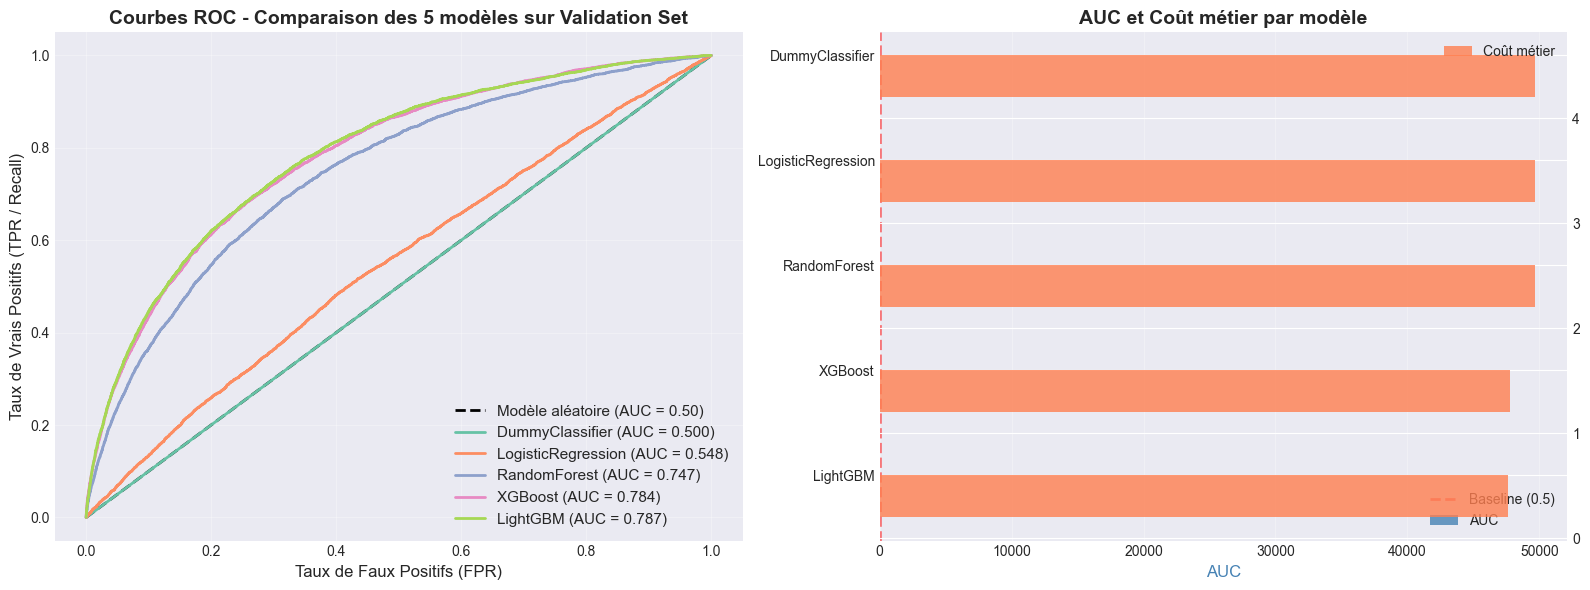

 Figure sauvegardée : nb03_fig01_comparaison_modeles.png


In [15]:
# Figure 1 : Courbes ROC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Courbes ROC
fpr_dummy, tpr_dummy, _ = roc_curve(y_valid, y_proba_dummy)
fpr_logreg, tpr_logreg, _ = roc_curve(y_valid, y_proba_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_valid, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_valid, y_proba_xgb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_valid, y_proba_lgbm)

ax1.plot([0, 1], [0, 1], 'k--', label='Modèle aléatoire (AUC = 0.50)', linewidth=2)
ax1.plot(fpr_dummy, tpr_dummy, label=f'DummyClassifier (AUC = {auc_dummy:.3f})', linewidth=2)
ax1.plot(fpr_logreg, tpr_logreg, label=f'LogisticRegression (AUC = {auc_logreg:.3f})', linewidth=2)
ax1.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {auc_rf:.3f})', linewidth=2)
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', linewidth=2)
ax1.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {auc_lgbm:.3f})', linewidth=2)
ax1.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax1.set_ylabel('Taux de Vrais Positifs (TPR / Recall)', fontsize=12)
ax1.set_title('Courbes ROC - Comparaison des 5 modèles sur Validation Set', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, alpha=0.3)

# Barres de comparaison AUC et Coût
x = np.arange(len(results))
ax2_twin = ax2.twinx()

bars1 = ax2.barh(x, results['AUC'], height=0.4, alpha=0.8, label='AUC', color='steelblue')
bars2 = ax2_twin.barh(x + 0.4, results['Coût métier'], height=0.4, alpha=0.8, label='Coût métier', color='coral')

ax2.set_yticks(x + 0.2)
ax2.set_yticklabels(results['Modèle'])
ax2.set_xlabel('AUC', fontsize=12, color='steelblue')
ax2_twin.set_xlabel('Coût métier (€)', fontsize=12, color='coral')
ax2.set_title('AUC et Coût métier par modèle', fontsize=14, fontweight='bold')
ax2.axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Baseline (0.5)')
ax2.legend(loc='lower right')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('nb03_fig01_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Figure sauvegardée : nb03_fig01_comparaison_modeles.png")

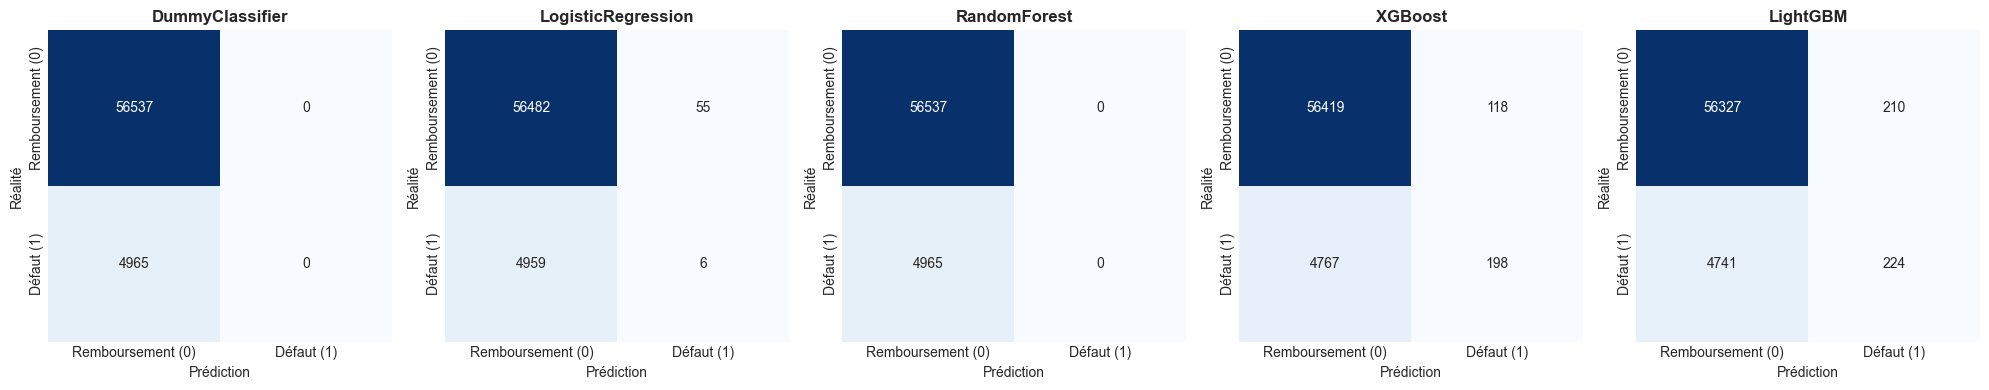

Figure sauvegardée : nb03_fig02_matrices_confusion.png


In [17]:
# Figure 2 : Matrices de confusion
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

cms = [
    confusion_matrix(y_valid, y_pred_dummy),
    confusion_matrix(y_valid, y_pred_logreg),
    confusion_matrix(y_valid, y_pred_rf),
    confusion_matrix(y_valid, y_pred_xgb),
    confusion_matrix(y_valid, y_pred_lgbm),
]
titles = ['DummyClassifier', 'LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM']

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Prédiction', fontsize=10)
    ax.set_ylabel('Réalité', fontsize=10)
    ax.set_xticklabels(['Remboursement (0)', 'Défaut (1)'])
    ax.set_yticklabels(['Remboursement (0)', 'Défaut (1)'])

plt.tight_layout()
plt.savefig('nb03_fig02_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : nb03_fig02_matrices_confusion.png")

## Sauvegarde du Meilleur Modèle

In [18]:
# ============================================================================
# SAUVEGARDE DU MEILLEUR MODÈLE (LightGBM optimisé via RandomizedSearchCV)
# ============================================================================

# Utiliser le modèle optimisé si disponible, sinon le LightGBM de base
try:
    modele_final = best_lgbm  # LightGBM optimisé par RandomizedSearchCV
    print("  Utilisation du modèle optimisé (RandomizedSearchCV)")
except NameError:
    modele_final = lgbm  # LightGBM de base
    print("  Utilisation du modèle LightGBM de base")

# Sauvegarder en local (pour l'API)
joblib.dump(modele_final, './artifacts/meilleur_modele.joblib')
print("  Modèle sauvegardé localement : ./artifacts/meilleur_modele.joblib")

# Sauvegarder les résultats de comparaison
results.to_csv('./artifacts/comparaison_modeles.csv', index=False)
print("  Résultats sauvegardés : ./artifacts/comparaison_modeles.csv")

# Résumé MLFlow
print("\n" + "="*70)
print(" RÉCAPITULATIF MLFlow")
print("="*70)
print(f"  Expérience : '{EXPERIMENT_NAME}'")
print(f"  Runs loggés : 6 (5 modèles + 1 RandomizedSearchCV best)")
print(f"  Model Registry : 'LightGBM_ScoringCredit'")
print(f"  Visualiser : mlflow ui --backend-store-uri ./mlruns")

print("\n" + "="*70)
print(" NOTEBOOK 03 TERMINÉ !")
print("="*70)


  Utilisation du modèle optimisé (RandomizedSearchCV)
  Modèle sauvegardé localement : ./artifacts/meilleur_modele.joblib
  Résultats sauvegardés : ./artifacts/comparaison_modeles.csv

 RÉCAPITULATIF MLFlow
  Expérience : 'P7_Comparaison_Modeles_Scoring_Credit'
  Runs loggés : 6 (5 modèles + 1 RandomizedSearchCV best)
  Model Registry : 'LightGBM_ScoringCredit'
  Visualiser : mlflow ui --backend-store-uri ./mlruns

 NOTEBOOK 03 TERMINÉ !
